This project aims to predict the presence of heart disease using machine learning techniques. The dataset contains medical information about patients, such as age, cholesterol level, chest pain type, maximum heart rate, and exercise-induced angina. The target variable is HeartDisease, where 0 represents no heart disease and 1 represents heart disease.

In [ ]:
# Step 1 — Load & Understand Heart Disease Dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/heart.csv")

In [ ]:
# Explore the dataset structure
print(df.shape)
print(df.dtypes)
df.info()
print(df.describe())
print(df.isnull().sum())
print(df["HeartDisease"].value_counts())
# The dataset was explored to understand its structure, size, data types, and target distribution. Basic functions such as head(), shape, info(), describe(), and isnull().sum() were used to inspect the dataset and identify any missing values or data quality issues.

(918, 12)
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope      

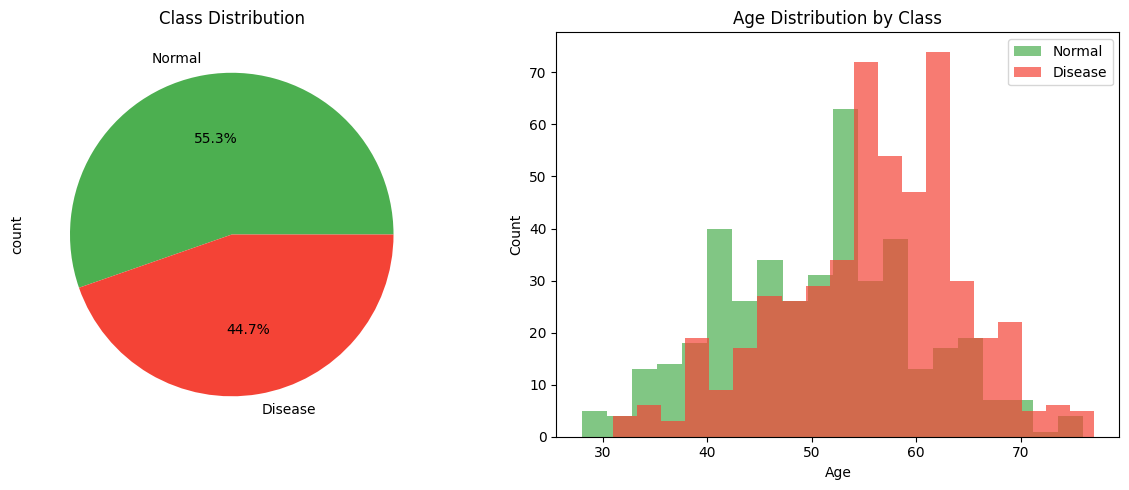

In [ ]:
# Plots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Pie chart: shows percentage of Normal vs Disease cases
df["HeartDisease"].value_counts().plot(kind="pie", labels=["Normal", "Disease"],
    autopct="%1.1f%%", colors=["#4CAF50", "#F44336"], ax=axes[0])
axes[0].set_title("Class Distribution")

for val, color, label in zip([0, 1], ["#4CAF50", "#F44336"], ["Normal", "Disease"]):
    df[df["HeartDisease"] == val]["Age"].plot(kind="hist", bins=20, alpha=0.7, color=color, label=label, ax=axes[1])
axes[1].legend()
axes[1].set(title="Age Distribution by Class", xlabel="Age", ylabel="Count")

plt.tight_layout()
plt.show()
# This project is a binary classification problem because the target variable HeartDisease has only two classes: 0 for no heart disease and 1 for heart disease. The goal is to train machine learning models to classify patients correctly based on their medical features.



In [ ]:
# Step 2 — Preprocessing

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for col in cat_cols:
    df[col] = le.fit_transform(df[col])  # Replace text values with numeric labels


In [ ]:
# Split features and target
X = df.drop("HeartDisease", axis=1) # All columns except the target
y = df["HeartDisease"] # Target column


In [ ]:
# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Scale features to have equal weight
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit on training data and transform it
X_test  = scaler.transform(X_test) # Apply same scale to test data

print(f"Train size: {X_train.shape}") # Show training set dimensions
print(f"Test size : {X_test.shape}") # Show test set dimensions


Train size: (734, 11)
Test size : (184, 11)


In [ ]:
#step3 — Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


colors = ["#4CAF50", "#F44336"]  # Green = Normal, Red = Disease
labels = ["Normal", "Disease"]
plt.rcParams.update({"font.size": 13})



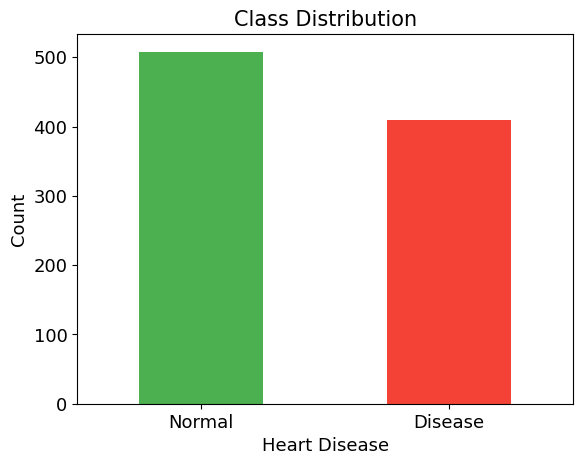

In [ ]:
# ──  Class Distribution ────────────────────────────────
df["HeartDisease"].value_counts().plot(kind="bar", color=colors) # Bar chart for class counts
plt.title("Class Distribution", fontsize=15)
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.xticks([0, 1], labels, rotation=0)
plt.show()
# The class distribution shows that the number of normal cases and heart disease cases is relatively balanced, which helps the models learn both classes without a severe imbalance problem.

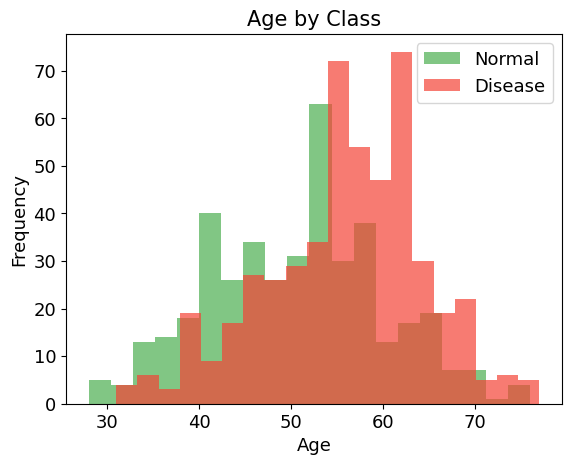

In [ ]:
# ── Age by Class ──────────────────────────────────────
for val, color, label in zip([0, 1], colors, labels):
    df[df["HeartDisease"] == val]["Age"].plot(kind="hist", bins=20, alpha=0.7, color=color, label=label)
plt.title("Age by Class", fontsize=15)
plt.xlabel("Age")
plt.legend()
plt.show()
# The age distribution shows that heart disease cases are more common among older patients, especially between ages 55 and 65, indicating that age is an important factor in predicting heart disease.

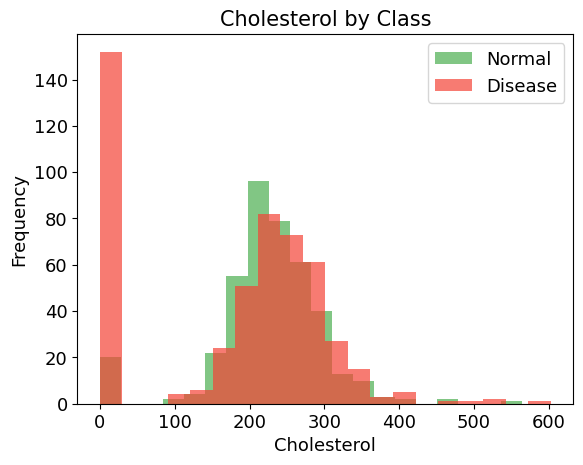

In [ ]:
# ── Cholesterol by Class ──────────────────────────────
for val, color, label in zip([0, 1], colors, labels):
    df[df["HeartDisease"] == val]["Cholesterol"].plot(kind="hist", bins=20, alpha=0.7, color=color, label=label)
plt.title("Cholesterol by Class", fontsize=15)
plt.xlabel("Cholesterol")
plt.legend()
plt.show()
# The cholesterol plot shows variation in cholesterol levels between normal and heart disease cases. Some cholesterol values are recorded as 0, which may indicate missing or incorrectly recorded values.


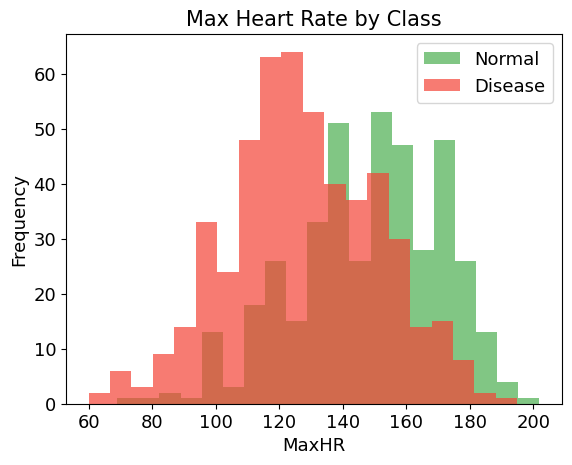

In [ ]:
# ── Max Heart Rate by Class ───────────────────────────
for val, color, label in zip([0, 1], colors, labels):
    df[df["HeartDisease"] == val]["MaxHR"].plot(kind="hist", bins=20, alpha=0.7, color=color, label=label)
plt.title("Max Heart Rate by Class", fontsize=15)
plt.xlabel("MaxHR")
plt.legend()
plt.show()
# The MaxHR distribution shows that normal patients generally have higher maximum heart rates, while heart disease patients tend to have lower MaxHR values. This makes MaxHR an important feature for prediction.

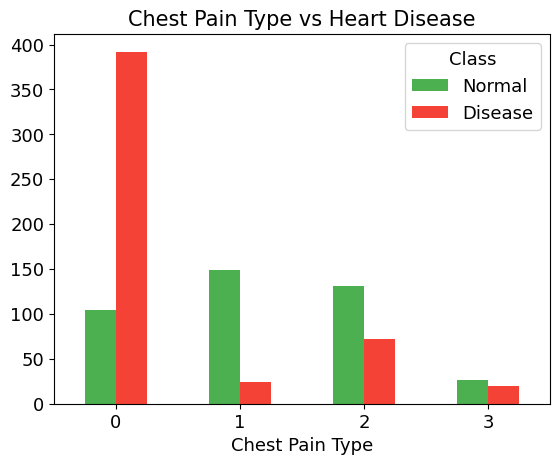

In [ ]:
# ── Chest Pain Type vs Heart Disease ──────────────────
# Crosstab creates a frequency table between two categorical columns
pd.crosstab(df["ChestPainType"], df["HeartDisease"]).plot(kind="bar", color=colors)
plt.title("Chest Pain Type vs Heart Disease", fontsize=15)
plt.xlabel("Chest Pain Type")
plt.legend(labels, title="Class")
plt.xticks(rotation=0)
plt.show()
# The chest pain type plot shows that the ASY type is strongly associated with heart disease cases, which indicates that chest pain type is an important categorical feature for classification.

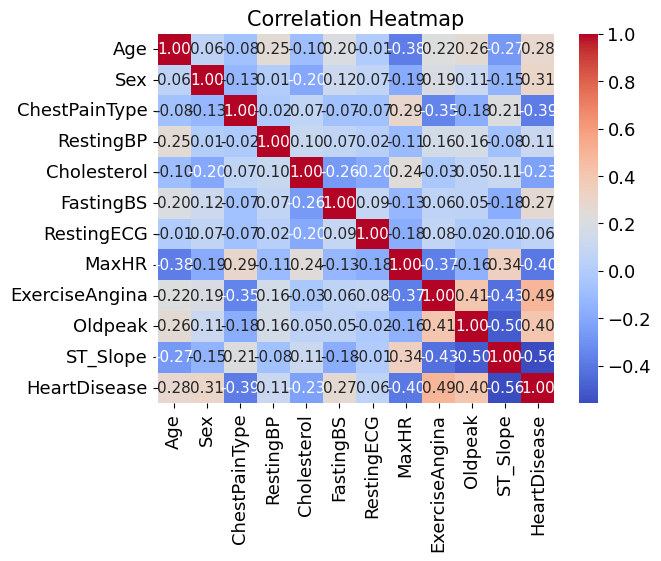

In [ ]:
# ── Correlation Heatmap ───────────────────────────────
num_df = df.select_dtypes(include="number")
# Draw heatmap showing correlation between all numeric features
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 11})
plt.title("Correlation Heatmap", fontsize=15)
plt.show()
# The correlation heatmap shows the relationship between features and the target variable. Features such as ST_Slope, ExerciseAngina, and MaxHR show stronger relationships with heart disease compared to other features.

In [ ]:
# Step 4 — Model Implementation

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("heart.csv")

# Data preprocessing was applied to prepare the dataset for machine learning models. Categorical columns were converted into numeric values using encoding because machine learning models cannot process text directly. The dataset was then split into features X and target y.
le = LabelEncoder()
for col in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]:
    df[col] = le.fit_transform(df[col])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# The dataset was split into training and testing sets. The training set was used to train the models, while the testing set was used to evaluate model performance on unseen data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
# StandardScaler was applied to scale the numerical features. Scaling helps models such as Logistic Regression perform better because it puts all features on a similar scale.

In [ ]:
# ── Logistic Regression + C comparison ────────────────
print("Logistic Regression - C comparison:")
for C in [0.01, 0.1, 1, 10, 100]:
    lr = LogisticRegression(C=C)
    lr.fit(X_train, y_train)
    print(f"  C={C:<6} -> Accuracy: {lr.score(X_test, y_test):.2f}")

# Best model
lr = LogisticRegression(C=1)
lr.fit(X_train, y_train)

# Logistic Regression was used as the first classification model. It is a simple and interpretable model commonly used for binary classification problems, making it suitable as a baseline model.
# Different hyperparameter values were tested to improve model performance. For Logistic Regression, different C values were compared, and for Random Forest, different numbers of estimators were tested.

Logistic Regression - C comparison:
  C=0.01   -> Accuracy: 0.84
  C=0.1    -> Accuracy: 0.84
  C=1      -> Accuracy: 0.85
  C=10     -> Accuracy: 0.84
  C=100    -> Accuracy: 0.84


LogisticRegression(C=1)

In [ ]:
# ── Random Forest + n_estimators comparison ───────────
# n_estimators = number of trees in the forest
print("Random Forest - n_estimators comparison:")
for n in [10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    print(f"  n_estimators={n:<4} -> Accuracy: {rf.score(X_test, y_test):.2f}")

# Best model: n_estimators=50 gives highest accuracy
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
# Random Forest was used as the second classification model. It combines multiple decision trees to improve prediction performance and can handle complex relationships between features.

Random Forest - n_estimators comparison:
  n_estimators=10   -> Accuracy: 0.88
  n_estimators=50   -> Accuracy: 0.89
  n_estimators=100  -> Accuracy: 0.88
  n_estimators=200  -> Accuracy: 0.88


RandomForestClassifier(random_state=42)

In [ ]:
# Step 5 — Evaluation & Comparison
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)


# Preprocessing
le = LabelEncoder()
for col in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]:
    df[col] = le.fit_transform(df[col])

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)




In [ ]:
# Train best models
lr = LogisticRegression(C=1)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
# ── Metrics Comparison ────────────────────────────────
models = {"Logistic Regression": lr, "Random Forest": rf}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, y_pred),  # Overall correct predictions
        "Precision": precision_score(y_test, y_pred), # How precise positive predictions are
        "Recall"   : recall_score(y_test, y_pred), # How many actual positives caught
        "F1 Score" : f1_score(y_test, y_pred), # Balance between precision & recall
        "ROC-AUC"  : roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), # Area under ROC curve
    })

results_df = pd.DataFrame(results).set_index("Model").round(2)
print(results_df)
# The models were evaluated using several metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. These metrics provide a more complete understanding of model performance than accuracy alone.


                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression      0.85       0.91    0.82      0.86     0.90
Random Forest            0.88       0.90    0.90      0.90     0.94


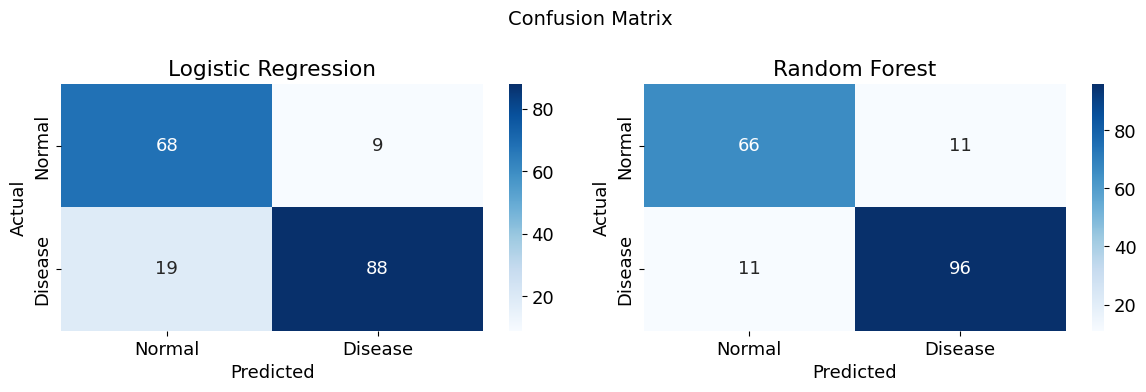

In [ ]:
# ──Confusion Matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Disease"],
                yticklabels=["Normal", "Disease"])
    ax.set(title=f"{name}", xlabel="Predicted", ylabel="Actual")

plt.suptitle("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()
# The confusion matrix shows how many cases were classified correctly and incorrectly. Random Forest missed fewer heart disease cases compared to Logistic Regression, which makes it more reliable for disease detection.



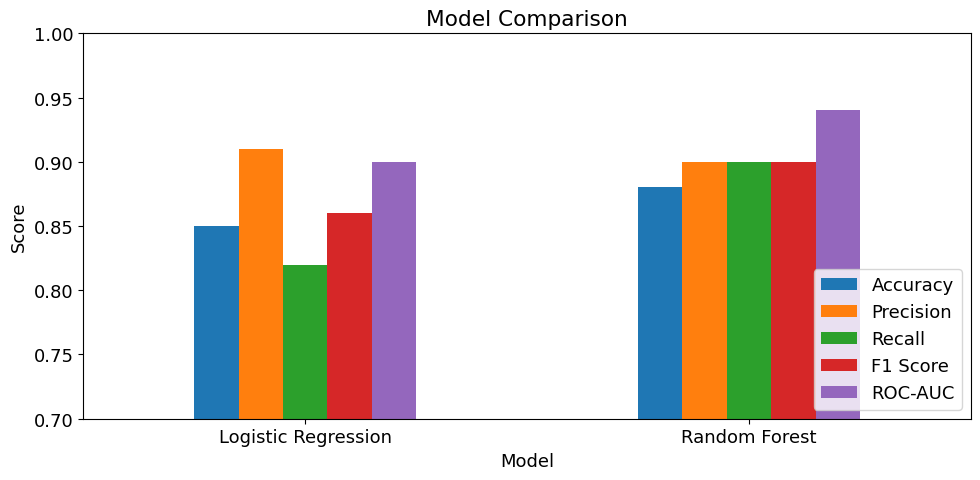

In [ ]:
# ──  Metrics Bar Chart ─────────────────────────────────
results_df.plot(kind="bar", figsize=(10, 5), ylim=(0.7, 1.0))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
# Random Forest achieved better overall performance than Logistic Regression across most evaluation metrics. Therefore, Random Forest was selected as the best model for this dataset.


In [ ]:

# ── Classification Report ────────────────────────────
for name, model in models.items():
    print(f"\n{name}:")
    print(classification_report(y_test, model.predict(X_test),
                                target_names=["Normal", "Disease"]))
    # Conclusion: Random Forest is the better model for this dataset


Logistic Regression:
              precision    recall  f1-score   support

      Normal       0.78      0.88      0.83        77
     Disease       0.91      0.82      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


Random Forest:
              precision    recall  f1-score   support

      Normal       0.86      0.86      0.86        77
     Disease       0.90      0.90      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In conclusion, the project successfully applied machine learning techniques to predict heart disease. After preprocessing the data, two classification models were trained and compared. Random Forest achieved the best performance, showing that it is more effective in detecting heart disease cases in this dataset.